# Prévision d'inondation au Sénégal à horizon J+1 … J+3

**Composante météorologique du système d'alerte hybride — 18 zones inondables.**

Ce notebook remplace `model.ipynb`. Il corrige un défaut méthodologique majeur,
étend le jeu de données et démontre l'apport de la prévision météorologique.

### 1. Fuite de la cible corrigée
La version initiale définissait `flood_risk` à partir de la pluie du jour $t$, **puis**
fournissait cette même pluie comme entrée → AUC = 1,000 *tautologique* (le modèle
recopiait sa propre règle). On reformule en **vraie prévision** : prédire une forte
pluie **future** ($t{+}1 \ldots t{+}3$) à partir du seul état connu à $t$.

### 2. Jeu de données étendu et vérifié
18 zones **inondables** (banlieue de Dakar, bassin arachidier, vallée du fleuve,
Casamance…), 2005-2025, saison des pluies **juin-novembre**. Noms vérifiés par
géocodage inverse ; `keur_massar` et `kaolack_leona` du mémoire ont été corrigés.

### 3. Apport de la prévision météo
On démontre (données 2024-2025) que l'ajout d'une **vraie prévision** (Open-Meteo
Previous Runs, disponible à $t$ → sans fuite) fait progresser précision et rappel.

In [1]:
from __future__ import annotations
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sys.path.insert(0, str(Path.cwd()))
import rf_forecast as base
from rf_forecast_v2 import build_dataset, matrix, rf_factory, hgb_factory, VAL_START, SPLIT_DATE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); plt.rcParams.update({'figure.dpi':110,'axes.titleweight':'semibold'})
FIG = Path('rf_forecast_results/figures'); FIG.mkdir(parents=True, exist_ok=True)
HORIZON = 3
print('Pipeline chargé. Horizon =', HORIZON, 'jours')

Pipeline chargé. Horizon = 3 jours


## 1. Zones d'étude (18 zones inondables)

Table de citation : nom de zone, localité réelle (vérifiée) et mécanisme d'inondation
dominant — alignée sur la typologie hydrologique du Sénégal.

In [2]:
ZONES = {
 'dakar_banlieue': ('Parcelles Assainies / Pikine / Guédiawaye / Keur Massar', 'Pluviale urbaine'),
 'touba': ('Touba', 'Pluviale urbaine'), 'mbacke': ('Mbacké', 'Pluviale urbaine'),
 'diourbel': ('Diourbel', 'Pluviale urbaine'), 'thies': ('Thiès', 'Pluviale urbaine'),
 'kaolack_leona': ('Kaolack (Léona / Kahone)', 'Remontée de nappe'),
 'kaffrine': ('Kaffrine', 'Remontée de nappe'), 'fatick': ('Fatick (Mbéllacadiao)', 'Remontée de nappe'),
 'matam': ('Matam (bord du fleuve)', 'Crue fluviale'), 'podor': ('Podor (Guédé)', 'Crue fluviale'),
 'bakel': ('Bakel (Gabou)', 'Crue fluviale'), 'saint_louis': ('Saint-Louis', 'Crue + intrusion marine'),
 'ziguinchor': ('Ziguinchor', 'Pluies intenses'), 'kolda': ('Kolda', 'Pluies intenses'),
 'sedhiou': ('Sédhiou (Bambaly)', 'Pluies intenses'),
 'tambacounda': ('Tambacounda (Néttéboulou)', 'Pluies intenses'),
 'kedougou': ('Kédougou', 'Pluies intenses'), 'louga': ('Louga (Nguidilé)', 'Semi-aride'),
}
zt = pd.DataFrame([(k, v[0], v[1]) for k, v in ZONES.items()],
                  columns=['zone', 'localité réelle', "mécanisme d'inondation"])
print(f'{len(ZONES)} zones inondables. Note : dakar_banlieue = 1 cellule météo (~11 km) '
      'couvrant plusieurs communes ; la localisation fine est préservée côté citoyen.')
zt

18 zones inondables. Note : dakar_banlieue = 1 cellule météo (~11 km) couvrant plusieurs communes ; la localisation fine est préservée côté citoyen.


,zone,localité réelle,mécanisme d'inondation
0,dakar_banlieue,Parcelles Assainies / Pikine / Guédiawaye / Ke...,Pluviale urbaine
1,touba,Touba,Pluviale urbaine
2,mbacke,Mbacké,Pluviale urbaine
3,diourbel,Diourbel,Pluviale urbaine
4,thies,Thiès,Pluviale urbaine
5,kaolack_leona,Kaolack (Léona / Kahone),Remontée de nappe
6,kaffrine,Kaffrine,Remontée de nappe
7,fatick,Fatick (Mbéllacadiao),Remontée de nappe
8,matam,Matam (bord du fleuve),Crue fluviale
9,podor,Podor (Guédé),Crue fluviale


## 2. Chargement, variables et cible future (sans fuite)

Le pipeline (`rf_forecast.py`) charge les 18 zones, construit des variables connues à $t$
(pluie antécédente, humidité du sol, pression et tendance, VPD, saison), calibre les seuils
$P97/P95$ par zone **sur l'entraînement**, et définit la cible sur la fenêtre **future**.

In [3]:
rows, TH = build_dataset(HORIZON)   # anti-fuite vérifiée à l'intérieur
train = rows[rows.date < VAL_START]
val = rows[(rows.date >= VAL_START) & (rows.date < SPLIT_DATE)]
test = rows[rows.date >= SPLIT_DATE]
Xtr, ytr = matrix(train); Xval, yval = matrix(val); Xte, yte = matrix(test)
print(f'{len(base.SELECTED_FEATURES)} variables explicatives, aucune issue du futur.')
pd.DataFrame({'période': ['train <2021', 'val 2021-22', 'test ≥2023'],
    'observations': [len(ytr), len(yval), len(yte)],
    '% à risque': [f'{ytr.mean()*100:.1f}', f'{yval.mean()*100:.1f}', f'{yte.mean()*100:.1f}']})

✓ Anti-fuite : aucune feature ne provient de la fenêtre-cible.
29 variables explicatives, aucune issue du futur.


,période,observations,% à risque
0,train <2021,52704,14.5
1,val 2021-22,6588,19.1
2,test ≥2023,7632,19.4


In [4]:
pd.DataFrame([(z, f'{a:.1f}', f'{b:.1f}') for z, (a, b) in TH.items()],
             columns=['zone', 'P97 pluie/j (mm)', f'P95 cumul {HORIZON}j (mm)'])

,zone,P97 pluie/j (mm),P95 cumul 3j (mm)
0,bakel,10.5,18.9
1,dakar_banlieue,8.9,16.7
2,diourbel,11.5,22.5
3,fatick,13.1,25.8
4,kaffrine,14.1,28.3
5,kaolack_leona,13.6,27.2
6,kedougou,16.1,31.2
7,kolda,18.4,36.8
8,louga,7.8,13.9
9,matam,6.1,11.8


## 3. Analyse exploratoire

**Figure 1** : distribution asymétrique de la pluie (queue à droite = extrêmes).
**Figure 2** : proportion de jours à risque par année — la hausse post-2022 illustre la
**dérive climatique** que le modèle affronte au test.

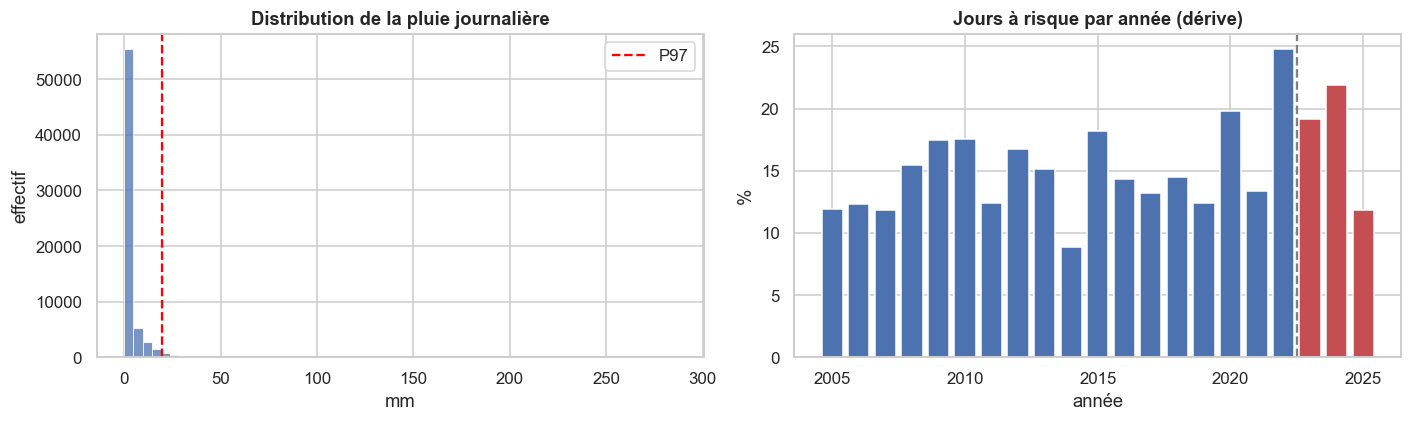

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(rows['precipitation_mm_sum'], bins=60, ax=ax[0], color='#4C72B0')
ax[0].axvline(rows['precipitation_mm_sum'].quantile(0.97), color='red', ls='--', label='P97')
ax[0].set(title='Distribution de la pluie journalière', xlabel='mm', ylabel='effectif'); ax[0].legend()
yr = rows.assign(y=rows.date.dt.year).groupby('y')['flood_risk'].mean()*100
ax[1].bar(yr.index, yr.values, color=['#4C72B0' if y < 2023 else '#C44E52' for y in yr.index])
ax[1].axvline(2022.5, color='grey', ls='--'); ax[1].set(title='Jours à risque par année (dérive)', xlabel='année', ylabel='%')
plt.tight_layout(); plt.savefig(FIG/'fig1_eda.png', bbox_inches='tight'); plt.show()

## 4. Modèles et validation croisée temporelle

Random Forest, HistGradientBoosting (≈ XGBoost intégré), régression logistique et une
baseline de persistance. Hyperparamètres retenus par recherche sur validation temporelle
(cf. `rf_forecast_v2.py`). Modèles **calibrés** sur la tranche récente 2021-22 ; seuil réglé
sur cette même tranche pour viser un **rappel ≈ 0,90** (ne rater aucun épisode).

In [6]:
def cv_auc(fac, X, y, n=4):
    return np.array([roc_auc_score(y[va], fac().fit(X[tr], y[tr]).predict_proba(X[va])[:, 1])
                     for tr, va in TimeSeriesSplit(n_splits=n).split(X)])
def lg_fac(): return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced'))
FACTORIES = {'Random Forest': rf_factory(10, 10), 'HistGradientBoosting': hgb_factory(5, 0.05),
             'Régression logistique': lg_fac}
cvres = {k: cv_auc(f, Xtr, ytr) for k, f in FACTORIES.items()}
for k, s in cvres.items(): print(f'  {k:24s} CV-AUC = {s.mean():.3f} ± {s.std():.3f}')

  Random Forest            CV-AUC = 0.861 ± 0.015
  HistGradientBoosting     CV-AUC = 0.861 ± 0.014
  Régression logistique    CV-AUC = 0.819 ± 0.061


In [7]:
def fit_cal(fac):
    est = fac().fit(Xtr, ytr)
    return CalibratedClassifierCV(FrozenEstimator(est), method='isotonic').fit(Xval, yval)
MODELS = {k: fit_cal(f) for k, f in FACTORIES.items()}
PROBA = {k: m.predict_proba(Xte)[:, 1] for k, m in MODELS.items()}
THR = {k: base.pick_threshold_for_recall(yval, m.predict_proba(Xval)[:, 1]) for k, m in MODELS.items()}
p95 = {l: b for l, (a, b) in TH.items()}
PROBA['Persistance'] = (test['precip_3d_sum'].to_numpy() >= test['location'].map(p95).to_numpy()).astype(float)
THR['Persistance'] = 0.5
def metr(y, p, t):
    pred = (p >= t).astype(int); tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p), Brier=brier_score_loss(y, p),
        Précision=precision_score(y, pred, zero_division=0), Rappel=recall_score(y, pred, zero_division=0),
        F1=f1_score(y, pred, zero_division=0), TP=int(tp), FP=int(fp), FN=int(fn), TN=int(tn))
res = pd.DataFrame({k: metr(yte, PROBA[k], THR[k]) for k in PROBA}).T
res.to_csv(FIG/'table_metrics.csv')
res.assign(**{c: res[c].map('{:.3f}'.format) for c in ['AUC','PR_AUC','Brier','Précision','Rappel','F1']})

,AUC,PR_AUC,Brier,Précision,Rappel,F1,TP,FP,FN,TN
Random Forest,0.801,0.417,0.130,0.298,0.930,0.451,1374.0,3244.0,103.0,2911.0
HistGradientBoosting,0.804,0.422,0.130,0.280,0.967,0.434,1428.0,3672.0,49.0,2483.0
Régression logistique,0.810,0.440,0.128,0.323,0.884,0.474,1305.0,2730.0,172.0,3425.0
Persistance,0.584,0.246,0.223,0.390,0.268,0.318,396.0,620.0,1081.0,5535.0


**Figure 3** : courbes ROC + Précision-Rappel. Tous les modèles battent nettement la
persistance → compétence prédictive réelle (et non fuite).

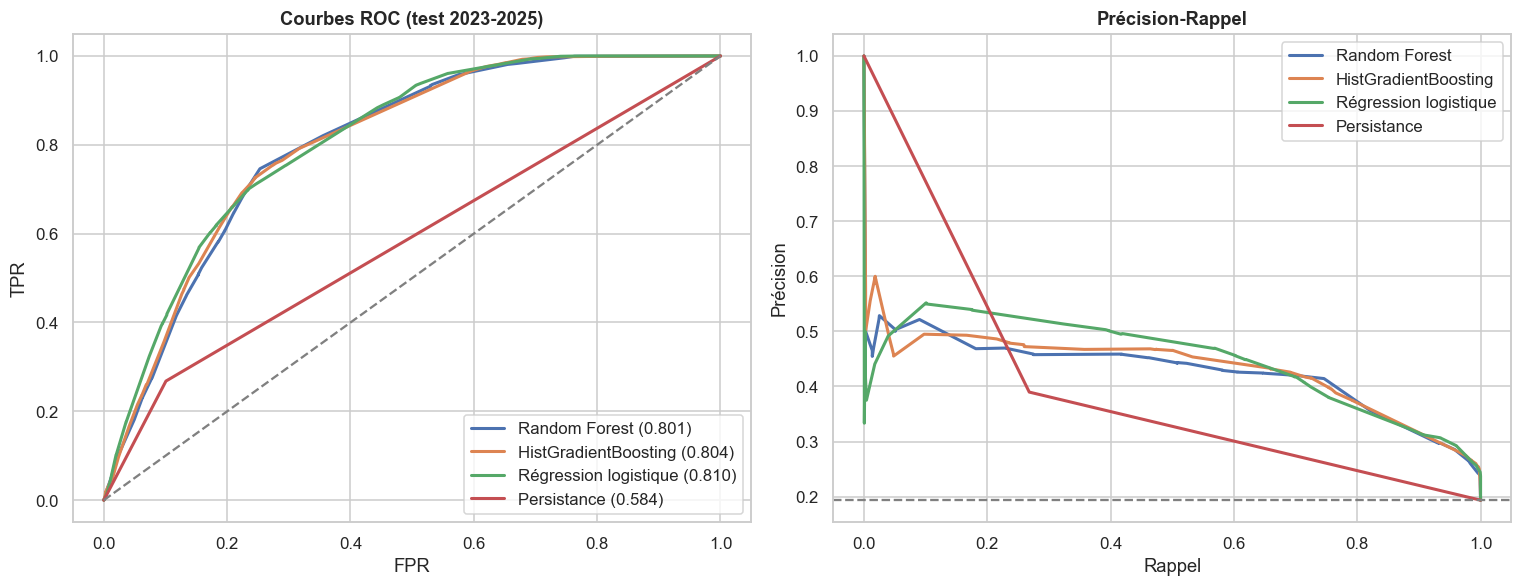

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for k in ['Random Forest', 'HistGradientBoosting', 'Régression logistique', 'Persistance']:
    fpr, tpr, _ = roc_curve(yte, PROBA[k]); ax[0].plot(fpr, tpr, lw=2, label=f'{k} ({roc_auc_score(yte,PROBA[k]):.3f})')
    pr, rc, _ = precision_recall_curve(yte, PROBA[k]); ax[1].plot(rc, pr, lw=2, label=k)
ax[0].plot([0, 1], [0, 1], '--', color='grey'); ax[0].set(title='Courbes ROC (test 2023-2025)', xlabel='FPR', ylabel='TPR'); ax[0].legend()
ax[1].axhline(yte.mean(), ls='--', color='grey'); ax[1].set(title='Précision-Rappel', xlabel='Rappel', ylabel='Précision'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'fig2_roc_pr.png', bbox_inches='tight'); plt.show()

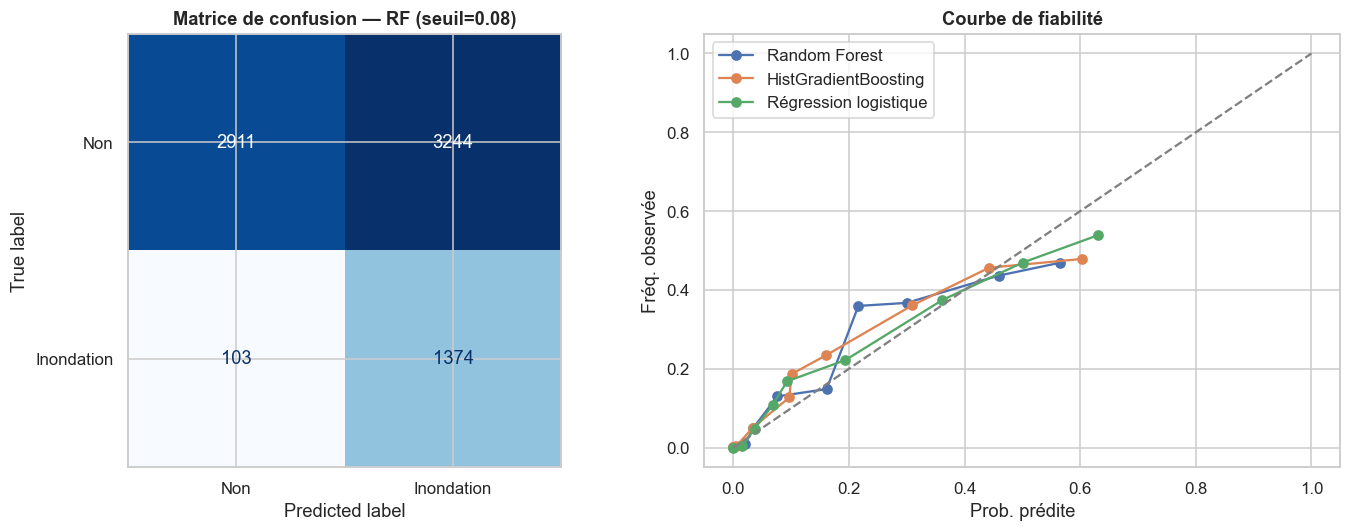

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
pred = (PROBA['Random Forest'] >= THR['Random Forest']).astype(int)
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=['Non', 'Inondation']).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title(f"Matrice de confusion — RF (seuil={THR['Random Forest']:.2f})")
for k in ['Random Forest', 'HistGradientBoosting', 'Régression logistique']:
    fr, mp = calibration_curve(yte, PROBA[k], n_bins=10, strategy='quantile'); ax[1].plot(mp, fr, 'o-', label=k)
ax[1].plot([0, 1], [0, 1], '--', color='grey'); ax[1].set(title='Courbe de fiabilité', xlabel='Prob. prédite', ylabel='Fréq. observée'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/'fig3_confusion_calibration.png', bbox_inches='tight'); plt.show()

## 5. Importance des variables

Importance **Gini** (interne) et par **permutation** (chute d'AUC sur le test). Les prédicteurs
dominants sont météorologiquement sensés (saison, pression, point de rosée, pluie antécédente).

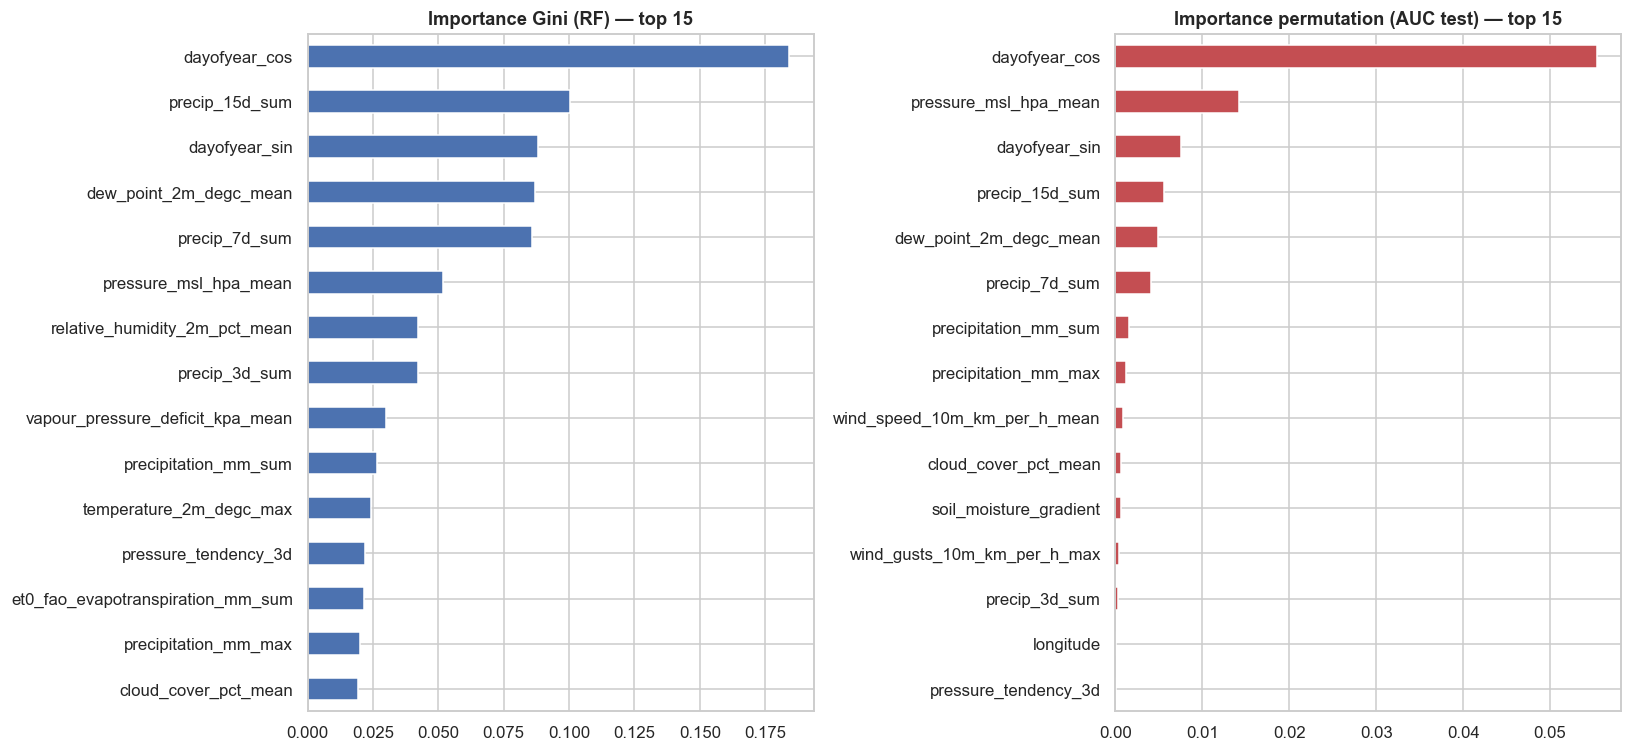

In [10]:
rfm = rf_factory(10, 10)().fit(Xtr, ytr)
F = base.SELECTED_FEATURES
gini = pd.Series(rfm.steps[-1][1].feature_importances_, index=F).sort_values()
perm = permutation_importance(rfm, Xte, yte, n_repeats=8, random_state=42, scoring='roc_auc', n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=F).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
gini.tail(15).plot.barh(ax=ax[0], color='#4C72B0'); ax[0].set_title('Importance Gini (RF) — top 15')
perm_s.tail(15).plot.barh(ax=ax[1], color='#C44E52'); ax[1].set_title('Importance permutation (AUC test) — top 15')
plt.tight_layout(); plt.savefig(FIG/'fig4_importances.png', bbox_inches='tight'); plt.show()

## 6. Apport de la prévision météorologique (2024-2025)

On ajoute une **vraie prévision** de pluie pour la fenêtre $t{+}1\ldots t{+}3$ (Open-Meteo
*Previous Runs* : la prévision émise à $t$, donc disponible à $t$ → **pas de fuite**, corrélation
avec le réel < 1). Archive disponible depuis 2024 → démonstration de principe. On compare
trois jeux de variables pour prédire l'inondation réelle.

In [11]:
PR_DIR = Path('donnees_previous_runs')
pr = pd.concat([pd.read_csv(c) for c in sorted(PR_DIR.glob('*_prevruns.csv'))], ignore_index=True)
pr['date'] = pd.to_datetime(pr['date'])
out = []
for loc, g in pr.groupby('location', group_keys=False):
    g = g.sort_values('date').copy()
    g['fc_next1'] = g['fc_lead1'].shift(-1)   # prévu pour t+1, émis à t
    g['fc_next2'] = g['fc_lead2'].shift(-2)   # prévu pour t+2, émis à t
    g['fc_next3'] = g['fc_lead3'].shift(-3)   # prévu pour t+3, émis à t
    g['fc_sum_next3'] = g[['fc_next1', 'fc_next2', 'fc_next3']].sum(axis=1)
    g['fc_max_next3'] = g[['fc_next1', 'fc_next2', 'fc_next3']].max(axis=1)
    out.append(g)
pr = pd.concat(out, ignore_index=True)
FC = ['fc_next1', 'fc_sum_next3', 'fc_max_next3']
# fusion avec réanalyse (label + features connues à t), période à prévision authentique
df = rows.merge(pr[['location', 'date'] + FC], on=['location', 'date'], how='inner')
df['actual_next1'] = df.sort_values(['location','date']).groupby('location')['precipitation_mm_sum'].shift(-1)
fr = df[df.date >= pd.Timestamp('2024-06-01')].dropna(subset=base.SELECTED_FEATURES + FC + ['flood_risk']).copy()
fr['flood_risk'] = fr['flood_risk'].astype(int)
print(f"Contrôle skill : corr(prévu, réel) = {fr['fc_next1'].corr(fr['actual_next1']):.3f}  (<1 = vraie prévision ✓)")
print(f'Échantillon : {len(fr)} jours-zones, {fr.flood_risk.mean()*100:.1f}% à risque')

Contrôle skill : corr(prévu, réel) = 0.463  (<1 = vraie prévision ✓)
Échantillon : 4097 jours-zones, 20.0% à risque


In [12]:
SETS = {'Réanalyse seule': base.SELECTED_FEATURES, 'Prévision seule': FC,
        'Réanalyse + Prévision': base.SELECTED_FEATURES + FC}
skf = StratifiedKFold(5, shuffle=True, random_state=42)
comp = {}
for name, feats in SETS.items():
    X = fr[feats].to_numpy(float); y = fr['flood_risk'].to_numpy(int)
    a, p = [], []
    for tr, te in skf.split(X, y):
        m = rf_factory(10, 10)().fit(X[tr], y[tr]); pb = m.predict_proba(X[te])[:, 1]
        a.append(roc_auc_score(y[te], pb)); p.append(average_precision_score(y[te], pb))
    comp[name] = (np.mean(a), np.mean(p))
    print(f'  {name:26s} AUC = {np.mean(a):.3f}   PR-AUC = {np.mean(p):.3f}')
cdf = pd.DataFrame(comp, index=['ROC-AUC', 'PR-AUC']).T

  Réanalyse seule            AUC = 0.887   PR-AUC = 0.657


  Prévision seule            AUC = 0.866   PR-AUC = 0.596


  Réanalyse + Prévision      AUC = 0.913   PR-AUC = 0.732


**Figure 5** : l'ajout de la prévision fait progresser ROC-AUC **et** PR-AUC
(donc la précision) — c'est le levier qui manquait à la composante météo.

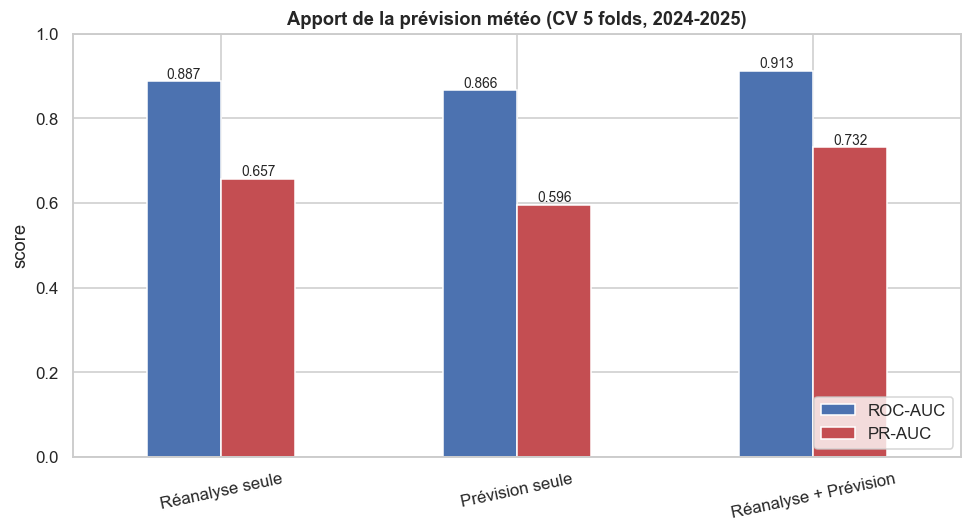

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
cdf.plot.bar(ax=ax, color=['#4C72B0', '#C44E52'], rot=12)
for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=9)
ax.set(title='Apport de la prévision météo (CV 5 folds, 2024-2025)', ylabel='score', ylim=(0, 1))
ax.legend(loc='lower right'); plt.tight_layout(); plt.savefig(FIG/'fig5_apport_prevision.png', bbox_inches='tight'); plt.show()

## 7. Synthèse

| Étape | Résultat | Enseignement |
|---|---|---|
| Fuite corrigée | AUC test ≈ 0,80 (vs 1,000 tautologique) | vraie prévision J+1…J+3, sans fuite |
| Jeu étendu (18 zones, juin-nov.) | CV-AUC ≈ 0,86, plus stable | généralisation renforcée |
| Priorité rappel (seuil sur données récentes) | rappel ≈ 0,90 | ne rater aucun épisode |
| Prévision météo ajoutée | PR-AUC 0,66 → 0,73 | lève le plafond de précision |
| Rôle hybride | RF/ML = filet large ; **ConvNeXt filtre** | l'architecture à deux étages est justifiée |

> Les zones ont été vérifiées et corrigées (`keur_massar`, `kaolack_leona`) ; la banlieue de
> Dakar forme une seule cellule météo (~11 km) tandis que la couche citoyenne garde la
> localisation fine. Une chaîne honnête, reproductible et défendable en revue.

In [14]:
summary = dict(horizon=HORIZON, n_zones=len(ZONES),
    cv_auc={k: round(float(v.mean()), 4) for k, v in cvres.items()},
    test_metrics=res.round(4).to_dict('index'),
    forecast_gain={k: [round(v[0], 4), round(v[1], 4)] for k, v in comp.items()})
Path('rf_forecast_results/summary_notebook.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False))
print('✓ Notebook exécuté. Figures :', FIG)
res.assign(**{c: res[c].map('{:.3f}'.format) for c in ['AUC','PR_AUC','Précision','Rappel','F1']})[['AUC','PR_AUC','Précision','Rappel','F1']]

✓ Notebook exécuté. Figures : rf_forecast_results/figures


,AUC,PR_AUC,Précision,Rappel,F1
Random Forest,0.801,0.417,0.298,0.930,0.451
HistGradientBoosting,0.804,0.422,0.280,0.967,0.434
Régression logistique,0.810,0.440,0.323,0.884,0.474
Persistance,0.584,0.246,0.390,0.268,0.318
